In [1]:
!pip install feedparser
import feedparser
import re
import pandas as pd
from datetime import datetime


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.5 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=5b0ec49d8ff3d366062b5f114be20198bf2f7eaeb3a81e96e9f41c016947a659
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [2]:
import feedparser
import re
import pandas as pd

# 1. Defined Tickers
STOCKS = ['NVDA', 'TSLA', 'AAPL']

def clean_summary(html_text):
    """Strips HTML tags and removes the source name often found in RSS snippets."""
    if not html_text: return ""
    clean = re.sub(r'<[^>]+>', '', html_text)
    return clean.split('...')[0] # Often RSS snippets end with ...

def fetch_ticker_news(ticker):
    # Search for ticker specific news from the last 7 days
    rss_url = f"https://news.google.com/rss/search?q={ticker}+stock+when:7d&hl=en-US&gl=US&ceid=US:en"
    feed = feedparser.parse(rss_url)

    entries = []
    for entry in feed.entries[:100]:
        entries.append({
            'ticker': ticker,
            'published_at': entry.published,
            'headline': entry.title,
            'summary': clean_summary(entry.get('summary', '')),
            'source': entry.get('source', {}).get('title', 'Unknown'),
            'link': entry.link
        })
    return pd.DataFrame(entries)

# Run the collection
all_news = pd.concat([fetch_ticker_news(s) for s in STOCKS])

In [3]:
source_frequency = all_news['source'].value_counts()
display(source_frequency)

,count
source,
The Motley Fool,32
MarketBeat,31
Yahoo Finance,30
Seeking Alpha,19
TipRanks,18
MSN,12
Meyka,10
24/7 Wall St.,9
Nasdaq,9


In [4]:
motley_fool_news = all_news[all_news['source'] == 'The Motley Fool']
display(motley_fool_news['headline'].head())

,headline
3,Nvidia Stock Just Did This for the First Time ...
11,Why Is Nvidia Stock Underperforming in 2026? -...
15,Nvidia Earnings on Feb. 25: What History Tells...
17,Is Nvidia Stock Going to $300? - The Motley Fool
19,Is Micron Technology Stock the Next Nvidia? - ...


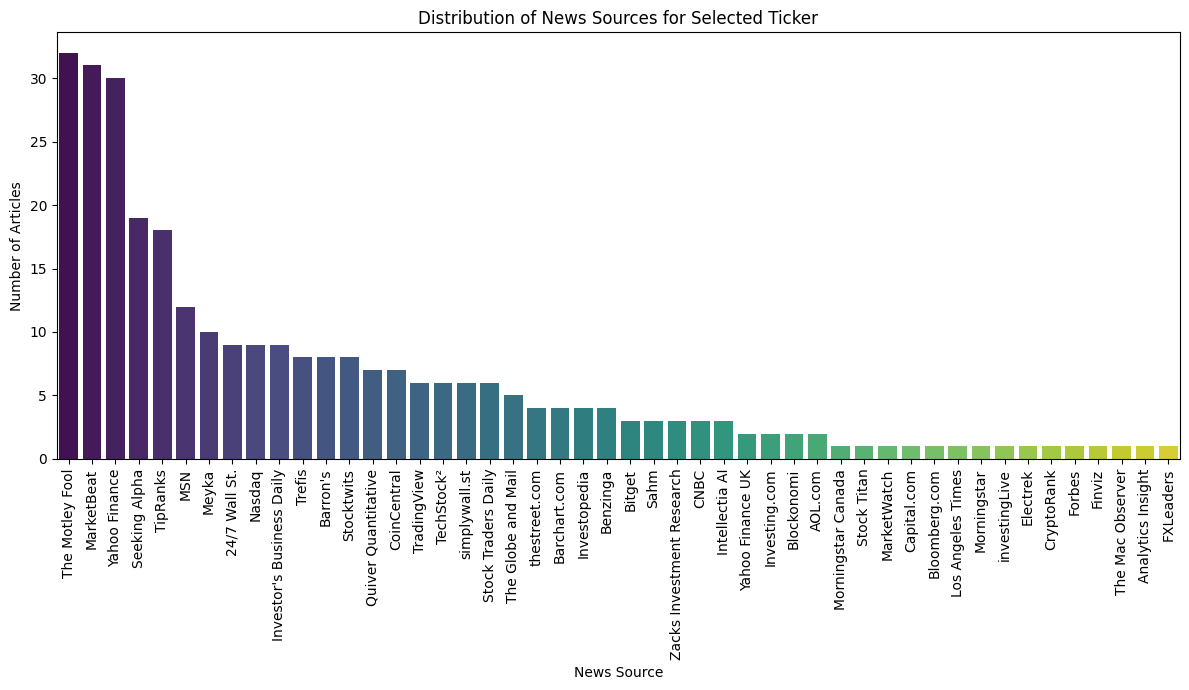

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=source_frequency.index, y=source_frequency.values, hue=source_frequency.index, palette='viridis', legend=False)
plt.title('Distribution of News Sources for Selected Ticker')
plt.xlabel('News Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
all_news_source_frequency = all_news['source'].value_counts()
motley_fool_count_all = all_news_source_frequency.get('The Motley Fool', 0)
print(f"Number of articles from 'The Motley Fool' in all_news: {motley_fool_count_all}")

Number of articles from 'The Motley Fool' in all_news: 32


In [7]:
# Save the fetched news data to a CSV file
all_news.to_csv('news_data.csv', index=False)
print("News data saved to news_data.csv")

News data saved to news_data.csv
